<a href="https://colab.research.google.com/github/Wanyiri9dave/crash-dataset-analysis/blob/main/crash_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Road Traffic Crash Analysis and Severity Prediction**

---



## **Project Overview**

The Vehicle Safety Board is responsible for improving road safety and minimizing fatalities. However, their current approach relies heavily on historical reporting rather than predictive insights, making it difficult to:

* Identify factors leading to severe crashes

* Proactively prevent high-risk situations

* Allocate emergency response resources efficiently

With access to detailed crash and vehicle datasets, there is an opportunity to develop a multi-class classification model that predicts crash severity (e.g., minor, serious, fatal) based on factors such as vehicle type, maneuver, and road conditions.

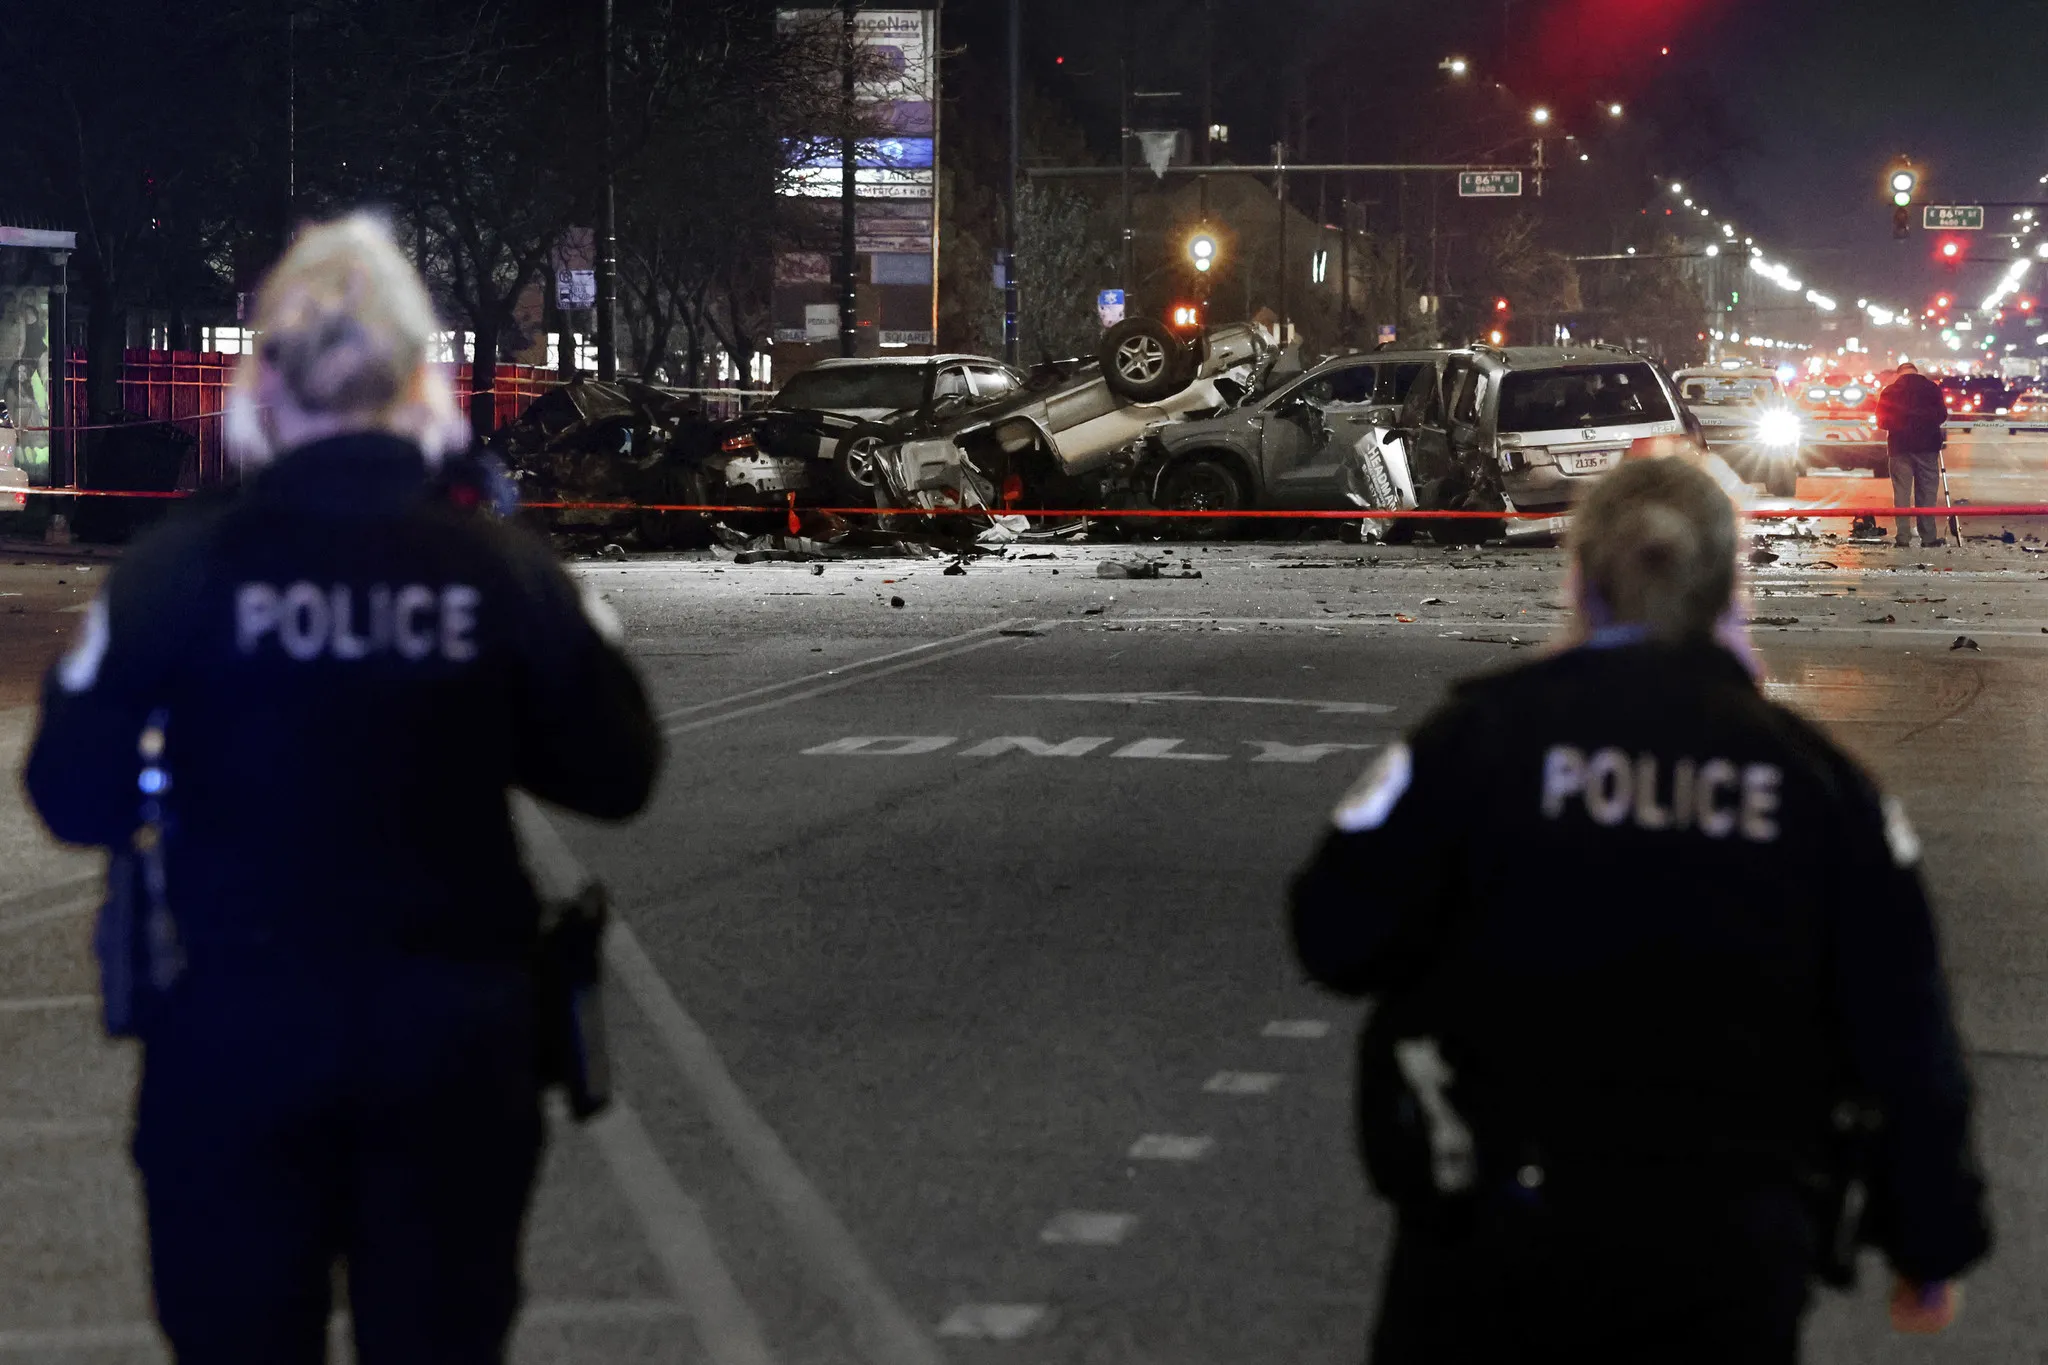

## **Project Objectives**

---



The primary objective of this project is to develop a robust, data-driven predictive model that enables the Vehicle Safety Board to accurately classify and predict the severity of traffic crashes using historical vehicle and incident data.

This will be achieved by analyzing key variables such as vehicle characteristics, driver behavior indicators (e.g., maneuver), and environmental conditions to identify patterns associated with different crash outcomes (e.g., no injury, minor injury, serious injury, fatal).

* Detect high-risk factors such as specific vehicle types, maneuvers, or conditions associated with severe crashes.

* Build and compare multiple multi-class classification models such as Decision Tree, Random Forest, and Logistic Regression.

* Provide recommendations to the Vehicle Safety Board for:

    Targeted safety intervention

    Improved traffic regulations

    Efficient allocation of emergency response


####  Importing Required libraries.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report
from scipy.stats import f_oneway

In [ ]:
df = pd.read_csv('/content/chicago_2019_2022.csv')
df.head()

/tmp/ipykernel_2246/2867013763.py:1: DtypeWarning: Columns (53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/chicago_2019_2022.csv')


,id,crash_date,crash_time,town,city,state,country,total_injured,total_killed,injury_incapacitated,...,windgust,windspeed,winddir,pressure,visibility,cloudcover,conditions,sunrise,sunset,moonphase
0,200319661,07/18/19,10:35,harwood heights,chicago,illinois,usa,0,0,0,...,\N,6.9,193.0,1013.9,1.8,54.6,"Rain, Partially cloudy",5:31:20,20:23:09,0.56
1,200320852,07/21/19,13:45,englewood,chicago,illinois,usa,0,0,0,...,\N,11.4,3.0,1013.3,7.4,87.4,"Rain, Partially cloudy",5:33:58,20:19:28,0.66
2,200320894,07/21/19,16:00,cragin,chicago,illinois,usa,0,0,0,...,\N,13.7,17.0,1013.6,9.9,58.2,"Rain, Partially cloudy",5:33:54,20:20:12,0.66
3,200320909,07/21/19,16:45,cragin,chicago,illinois,usa,0,0,0,...,\N,13.7,17.0,1013.6,9.9,58.3,"Rain, Partially cloudy",5:33:53,20:20:10,0.66
4,200320967,07/21/19,23:05,cicero,chicago,illinois,usa,0,0,0,...,\N,4.9,342.0,1018.4,9.9,0.0,Clear,5:34:53,20:19:06,0.69


# **Data Understanding**

---



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133801 entries, 0 to 133800
Data columns (total 65 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   id                                133801 non-null  int64  
 1   crash_date                        133801 non-null  object 
 2   crash_time                        133801 non-null  object 
 3   town                              133801 non-null  object 
 4   city                              133801 non-null  object 
 5   state                             133801 non-null  object 
 6   country                           133801 non-null  object 
 7   total_injured                     133801 non-null  object 
 8   total_killed                      133801 non-null  object 
 9   injury_incapacitated              133801 non-null  object 
 10  injury_non_incapacitated          133801 non-null  object 
 11  most_severe_injury                133801 non-null  o

* The dataset contains 126,493 crash records with 65 columns covering crash details, injuries, causes, location, date/time, and weather. It includes numeric, categorical, and object data types, with very few missing values. The target variable, crash_severity, has a fairly balanced distribution, while most_severe_injury is skewed toward minor or no injuries. Several numeric-like columns, such as injury counts and weather measurements, are stored as objects and require conversion, and date/time fields need proper parsing. High-cardinality features like city and contributory_cause may need grouping or encoding for modeling purposes. Overall, the dataset provides rich spatial, temporal, and environmental information, but careful preprocessing is needed before analysis or predictive modeling.


In [ ]:
df.describe()

,id,num_vehicles_in_crash,lattitude,longitude,days_tempmax,days_tempmin,days_temp,days_feelslikemax,days_feelslikemin,days_feelslike,...,humidity,dew,precip,precipprob,windspeed,winddir,pressure,visibility,cloudcover,moonphase
count,1.338010e+05,133801.000000,133801.000000,133801.000000,133800.000000,133800.000000,133800.000000,133800.000000,133800.000000,133800.000000,...,133800.000000,133800.000000,133800.000000,133800.000000,133800.000000,133800.000000,133800.000000,133800.000000,133800.000000,133800.000000
mean,2.004432e+08,2.040493,41.854035,-87.678563,60.646946,45.405969,52.940863,58.906615,41.037024,49.778265,...,62.295986,40.670616,0.004712,11.084454,10.323250,184.550192,1016.529658,9.150148,62.424444,0.482258
std,1.070747e+05,0.479822,0.143658,0.247046,21.247765,19.664609,20.162223,24.647559,24.170478,24.181661,...,17.691865,19.347358,0.028890,31.394071,4.985732,101.896997,7.589547,1.948046,31.718335,0.287855
min,2.002557e+08,1.000000,0.000000,-87.936193,-9.400000,-22.300000,-16.800000,-34.200000,-51.000000,-41.100000,...,10.600000,-32.200000,0.000000,0.000000,0.000000,0.000000,985.800000,0.000000,0.000000,0.000000
25%,2.003513e+08,2.000000,41.779084,-87.722352,42.700000,30.700000,36.800000,37.700000,23.400000,30.600000,...,48.800000,26.500000,0.000000,0.000000,6.800000,88.000000,1011.600000,9.900000,32.800000,0.250000
50%,2.004437e+08,2.000000,41.871778,-87.674594,62.000000,44.900000,53.300000,62.000000,40.700000,52.000000,...,62.700000,40.500000,0.000000,0.000000,9.900000,204.000000,1016.000000,9.900000,68.000000,0.480000
75%,2.005357e+08,2.000000,41.923636,-87.633527,79.700000,63.300000,71.500000,79.700000,63.300000,71.400000,...,76.100000,57.300000,0.000000,0.000000,13.400000,266.000000,1021.000000,9.900000,92.100000,0.750000
max,2.006278e+08,14.000000,42.022780,0.000000,101.000000,83.900000,91.200000,112.600000,88.300000,99.500000,...,100.000000,79.900000,1.118000,100.000000,37.800000,360.000000,1048.300000,15.000000,100.000000,0.980000


# **Data Cleaning & Preparation**

---



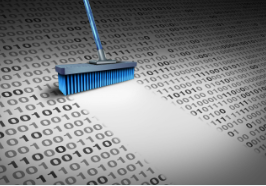

In [ ]:
# Convert Numeric-Like Object Columns

numeric_cols = [
    'total_injured', 'total_killed', 'injury_incapacitated', 'injury_non_incapacitated',
    'days_snow', 'days_snowdepth', 'days_windgust', 'days_precip', 'days_precipcover',
    'snow', 'snowdepth', 'windgust',
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

* Many columns that look numeric are stored as object. For example: total_injured, total_killed, injury_incapacitated, days_snow, etc. We need to convert them to proper numeric types so we can analyze or model them.

In [ ]:
# Parse Dates and Times

df['crash_date'] = pd.to_datetime(df['crash_date'], format='%m/%d/%y', errors='coerce')

* crash_date and crash_time are currently objects. We need them as datetime objects to extract features like hour, weekday, and month.

In [ ]:
# Create Temporal Features

# Extract hour from crash_time

df['hour'] = pd.to_datetime(df['crash_time'], format='%H:%M', errors='coerce').dt.hour


# Day of the week
df['weekday'] = df['crash_date'].dt.day_name()

# Month
df['month'] = df['crash_date'].dt.month

# Night vs Day indicator
df['is_night'] = ((df['hour'] < 6) | (df['hour'] > 18)).astype(int)

* From the date and time, we can create features that often help explain crash patterns:

In [ ]:
# Handle Missing Values

df.fillna({
    'road_defect': 'Unknown',
    'lattitude': df['lattitude'].median(),
    'longitude': df['longitude'].median()
}, inplace=True)

* The dataset has very few missing values, but we should still handle them systematically.

##### Feature Engineering

In [ ]:
# Spatial Features
# Example: Region cluster
from sklearn.cluster import KMeans

coords = df[['lattitude','longitude']].dropna()
kmeans = KMeans(n_clusters=10, random_state=1)
df['region_cluster'] = kmeans.fit_predict(coords)


* Helps capture geographic hotspots where crashes are more frequent which will also help in modelling.

In [ ]:
# Combine weather variables into more meaningful features

# Temperature range
df['temp_range'] = df['days_tempmax'] - df['days_tempmin']

# Wind + gust combined
df['wind_total'] = df['windspeed'] + df['windgust'].fillna(0)

# Hazard index example (simplified)
df['hazard_index'] = df['precip'].fillna(0) + df['snow'].fillna(0) + df['wind_total']

* single combined features like *hazard index* can summarize adverse weather for modeling.

In [ ]:
# creating a seasons column

def get_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Fall'
    else:
        return 'Winter'

df['season'] = df['crash_date'].dt.month.apply(get_season)

* A season feature can help  model capture broader environmental and behavioral patterns, improving both predictive power and interpretability.

In [ ]:
 # creating a time period feature for machine learning

 def time_period(hour):
    if 5 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 17:
        return 'afternoon'
    elif 17 <= hour < 21:
        return 'evening'
    else:
        return 'night'

df['time_period'] = df['hour'].apply(time_period)

In [ ]:
# Aggregate or combine vehicle and injury counts

# Total injuries (already exists but make numeric)
df['total_injuries'] = df['injury_incapacitated'] + df['injury_non_incapacitated']

# Injury per vehicle
df['injury_per_vehicle'] = df['total_injuries'] / df['num_vehicles_in_crash']

* Helps normalize injury severity relative to number of vehicles involved.

In [ ]:
# Categorical Grouping / Encoding

* High-cardinality features like *city* or *contributory_cause* can be grouped into broader categories or encoded using frequency/target encoding.

In [ ]:
# Frequency encoding
high_card_cols = ['city','contributory_cause']
for col in high_card_cols:
    freq = df[col].value_counts() / len(df)
    df[col+'_freq'] = df[col].map(freq)

* Low-cardinality features like crash_type can be one-hot encoded.

In [ ]:
df['original_crash_type'] = df['crash_type'] # Save original column
df = pd.get_dummies(df, columns=['crash_type','state','traffic_control_device'], drop_first=True)

In [ ]:
# Exporting dataset for modelling

cleaned_df.to_csv('cleaned_data.csv', index=False)

# **Exploratory Data Analysis(EDA)**

---



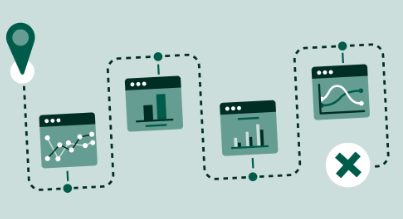

## Uni-variate Analysis.

* Univariate analysis looks at one variable at a time. It’s useful to understand distribution, missingness, and potential outliers.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


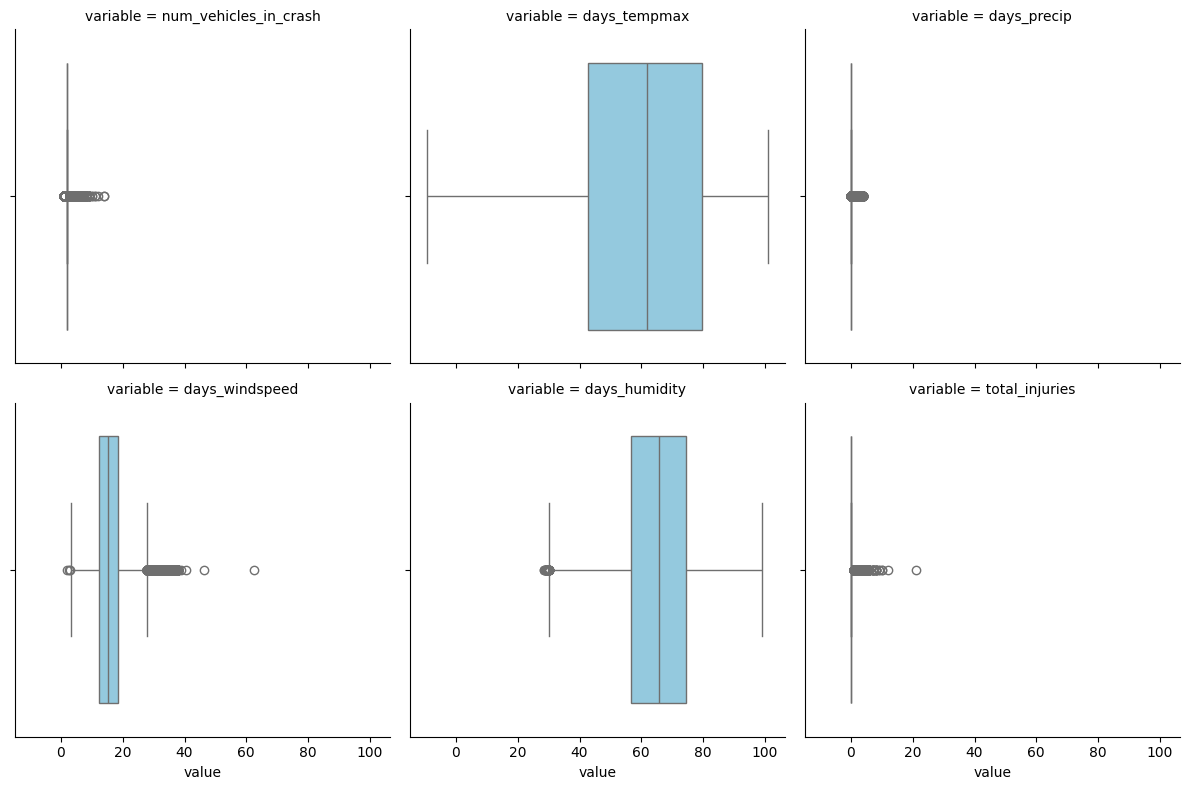

In [ ]:
# Melting the dataframe makes it easier to facet

df_melted = df[['num_vehicles_in_crash', 'days_tempmax', 'days_precip', 'days_windspeed', 'days_humidity','total_injuries']].melt()

g = sns.FacetGrid(df_melted, col="variable", sharey=False, col_wrap=3, height=4)
g.map(sns.boxplot, "value", color="skyblue")
plt.show()

* Temperature and humidity are well-distributed. There is a wide variety of "normal" weather in your data (e.g., humidity ranging from $40\%$ to $80\%$).

* It doesn't rain on most days . The outliers are the few days where it actually rained.

* Most days have a "standard" wind speed (around $15$ units), but high-wind events ($30$–$60$ units) happen frequently enough to be a distinct category of crashes.

In [ ]:
# Target Variable check

df['crash_severity'].value_counts()


,count
crash_severity,
major,41571
minor,24093


* Crash severity shows a moderate imbalance, with major crashes accounting for approximately 63% of cases and minor crashes 37%, indicating a slight skew that should be considered during model evaluation but does not require extensive imbalance handling.

<Axes: xlabel='total_injured', ylabel='Count'>

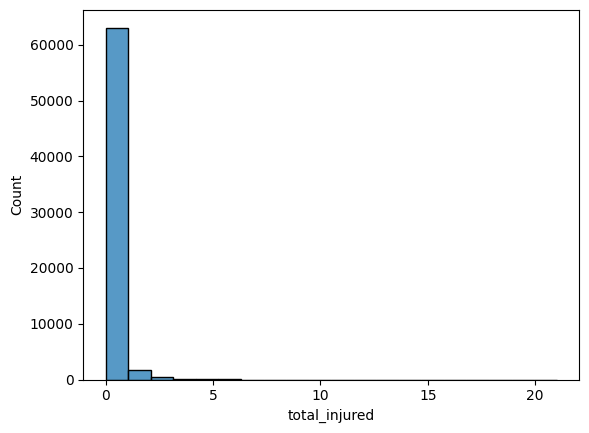

In [ ]:
df['total_injured'].describe()
sns.histplot(df['total_injured'], bins=20)

<Axes: xlabel='is_night', ylabel='crash_severity'>

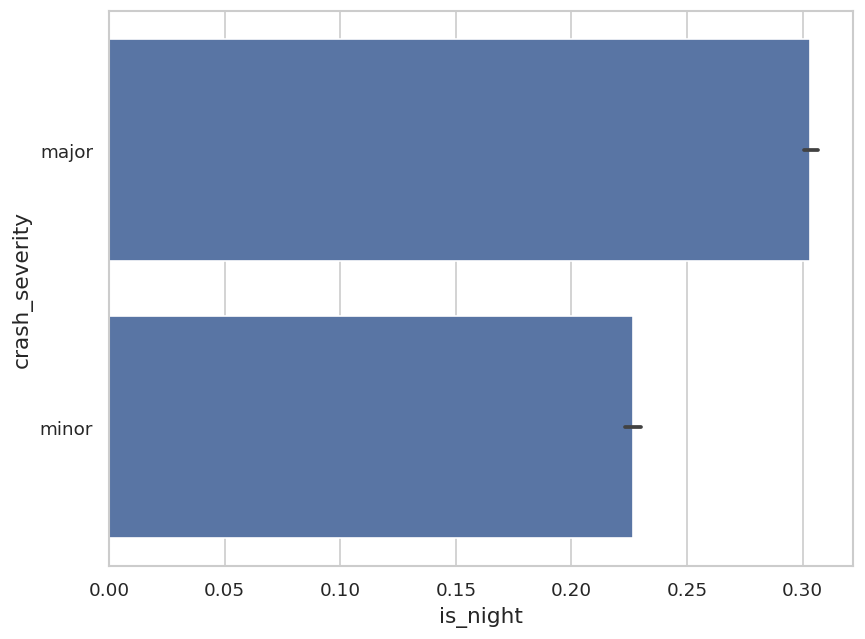

In [ ]:
sns.barplot(x='is_night', y='crash_severity', data=df)

# **visualizations**

---



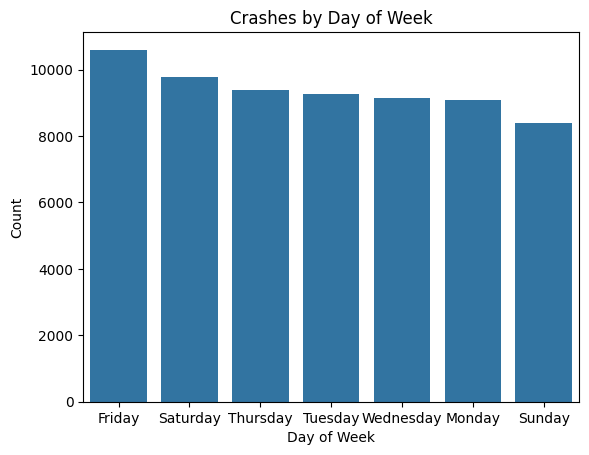

In [ ]:
sns.countplot(x='weekday', data=df, order=df['weekday'].value_counts().index)
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.title('Crashes by Day of Week')
plt.show()

* Crash frequency peaks toward the end of the week, with Friday and Saturday showing the highest counts, while Sunday records the lowest, indicating that traffic volume and social behavior significantly influence crash occurrence.

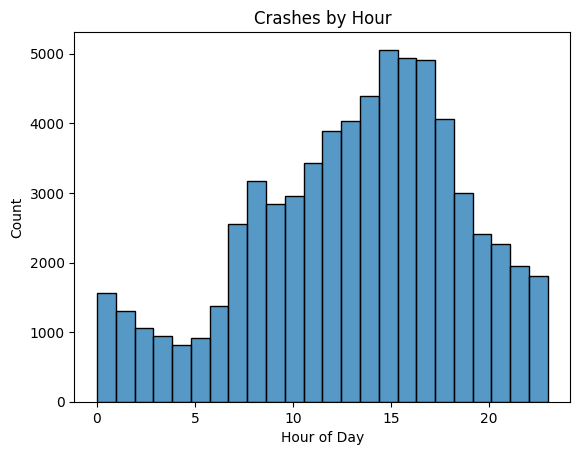

In [ ]:
sns.histplot(df['hour'], bins=24)
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.title('Crashes by Hour')
plt.show()

* Crash frequency increases steadily from early morning, peaks during late afternoon rush hours (3–5 PM), and declines into the night, reflecting the strong influence of traffic volume and daily human activity patterns on crash occurrence.

In [ ]:
# Are late-night crashes fewer but more severe ?

pd.crosstab(df['hour'], df['crash_severity'], normalize='index')

crash_severity,major,minor
hour,,
0,0.735219,0.264781
1,0.759174,0.240826
2,0.771831,0.228169
3,0.789979,0.210021
4,0.765068,0.234932
5,0.722404,0.277596
6,0.671273,0.328727
7,0.625147,0.374853
8,0.621656,0.378344


* Crash severity varies significantly by time of day, with early morning hours (2–4 AM) showing the highest proportion of severe crashes, while daytime hours exhibit lower severity despite higher crash frequency, indicating that lower traffic conditions are associated with more dangerous driving behavior.

In [ ]:
pd.crosstab(df['conditions'], df['crash_severity'], normalize='index')

crash_severity,major,minor
conditions,,
Clear,0.666834,0.333166
Overcast,0.643957,0.356043
Partially cloudy,0.624387,0.375613
Rain,0.666667,0.333333
"Rain, Overcast",0.653698,0.346302
"Rain, Partially cloudy",0.601781,0.398219
"Snow, Overcast",0.608808,0.391192
"Snow, Partially cloudy",0.674033,0.325967


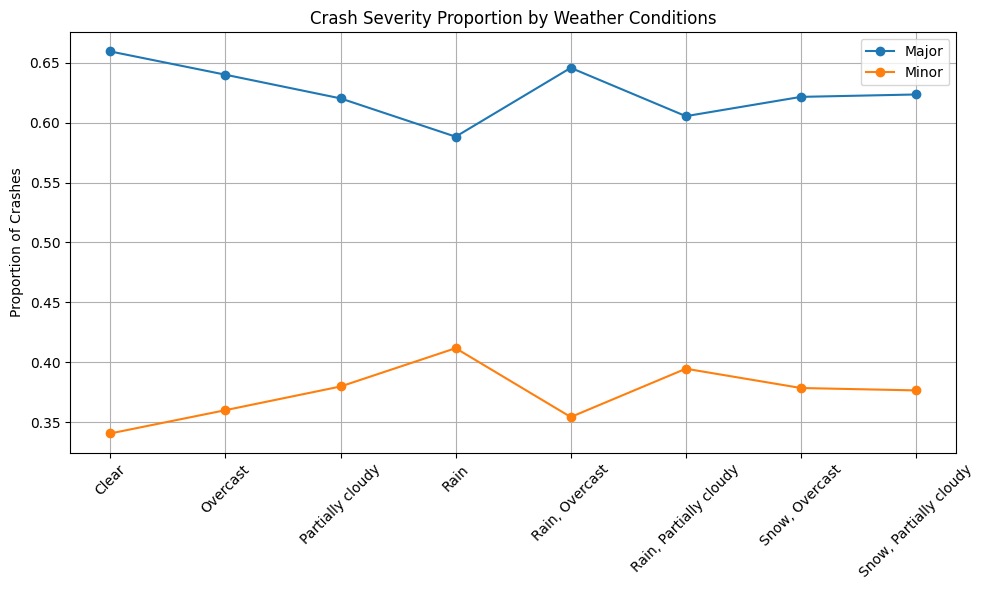

In [ ]:
conditions = [
    "Clear", "Overcast", "Partially cloudy", "Rain",
    "Rain, Overcast", "Rain, Partially cloudy",
    "Snow, Overcast", "Snow, Partially cloudy"
]

major = [0.659372, 0.639952, 0.620195, 0.588235, 0.645671, 0.605362, 0.621461, 0.623457]
minor = [0.340628, 0.360048, 0.379805, 0.411765, 0.354329, 0.394638, 0.378539, 0.376543]

plt.figure(figsize=(10,6))
plt.plot(conditions, major, marker='o', label='Major')
plt.plot(conditions, minor, marker='o', label='Minor')
plt.xticks(rotation=45)
plt.ylabel('Proportion of Crashes')
plt.title('Crash Severity Proportion by Weather Conditions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

* Clear weather has the highest proportion of major crashes. This may sound counterintuitive, but it could reflect higher speeds in good weather, increasing crash severity when accidents occur.

* Rain slightly increases minor crashes proportion, suggesting slippery conditions may cause more frequent but less severe accidents, or cautious driving reduces severity.

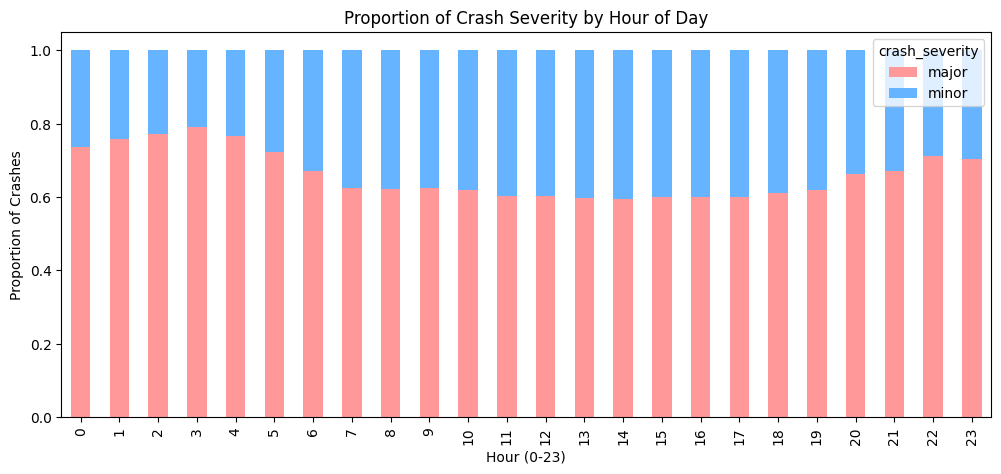

In [ ]:
# The "Rush Hour" Temporal Plot

# Create a cross-tabulation of Hour vs Severity
hourly_severity = pd.crosstab(df['hour'], df['crash_severity'], normalize='index')

hourly_severity.plot(kind='bar', stacked=True, figsize=(12, 5), color=['#ff9999','#66b3ff'])
plt.title('Proportion of Crash Severity by Hour of Day')
plt.ylabel('Proportion of Crashes')
plt.xlabel('Hour (0-23)')
plt.show()

* In crash data, time is often the #1 predictor. This plot shows if "Major" crashes are more frequent during late-night hours (due to fatigue/speed) compared to daytime rush hours.

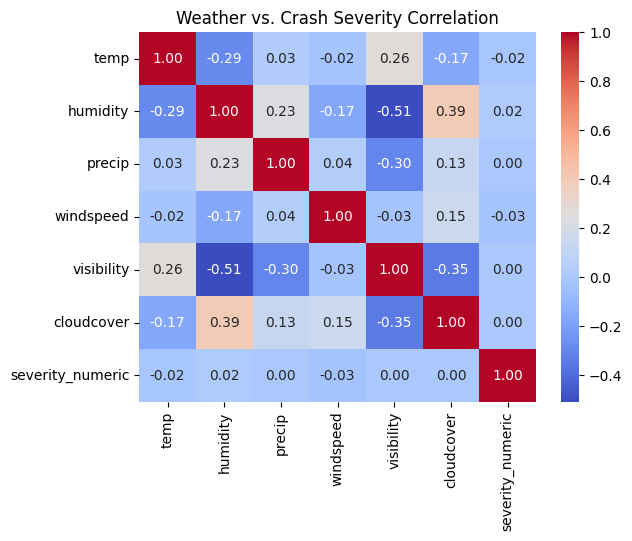

In [ ]:
# The Weather Correlation Heatmap

# Convert target to numeric for correlation (1 for Major, 0 for Minor)
df['severity_numeric'] = (df['crash_severity'] == 'major').astype(int)

# Select key weather features
weather_cols = ['temp', 'humidity', 'precip', 'windspeed', 'visibility', 'cloudcover', 'severity_numeric']
corr = df[weather_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Weather vs. Crash Severity Correlation')
plt.show()


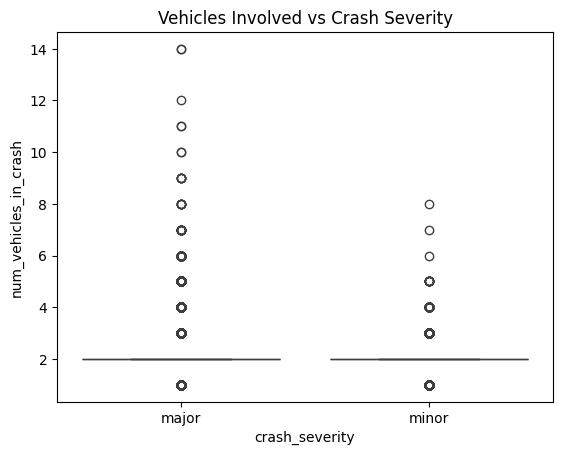

In [ ]:
# Number of Vehicles vs Severity

sns.boxplot(x='crash_severity', y='num_vehicles_in_crash', data=df)
plt.title('Vehicles Involved vs Crash Severity')
plt.show()

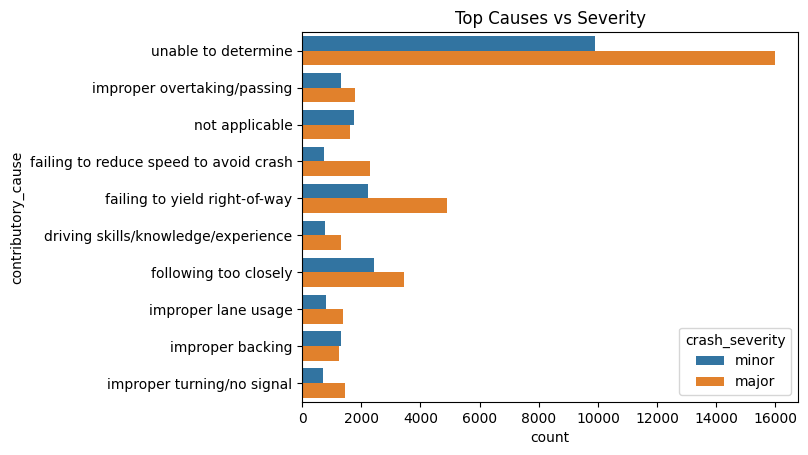

In [ ]:
# Contributory Cause vs Severity

top_causes = df['contributory_cause'].value_counts().head(10).index

subset = df[df['contributory_cause'].isin(top_causes)]

sns.countplot(y='contributory_cause', hue='crash_severity', data=subset)
plt.title('Top Causes vs Severity')
plt.show()

In [ ]:
# Geographic Map

import folium

# Ensure 'severity_numeric' is defined for the map
df['severity_numeric'] = (df['crash_severity'] == 'major').astype(int)

m = folium.Map(location=[df['lattitude'].mean(), df['longitude'].mean()], zoom_start=10)

for _, row in df.sample(n=1000).iterrows():  # sample for speed, using 1000 rows
    folium.CircleMarker(
        location=[row['lattitude'], row['longitude']],
        radius=3,
        color='red' if row['severity_numeric'] == 1 else 'blue', # Corrected column name and condition
        fill=True
    ).add_to(m)

m

* Spatial hotspots of severe crashes.

In [ ]:
# Global Styling

# Theme
sns.set_theme(style="whitegrid")

# Figure quality
plt.rcParams.update({
    "figure.figsize": (8, 6),
    "figure.dpi": 120,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

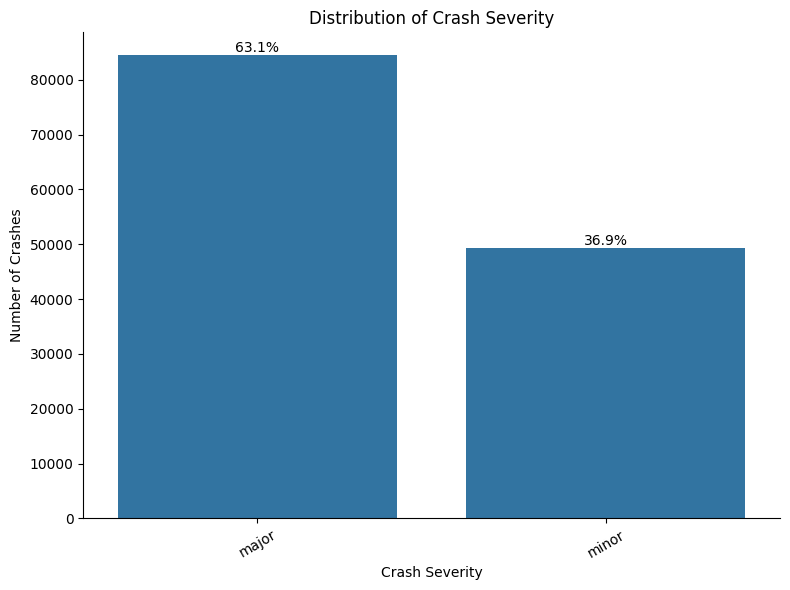

In [ ]:
# Severity Distribution (with percentages)

plt.figure(figsize=(8, 6)) # Set the figure size explicitly
ax = sns.countplot(x='crash_severity', data=df, order=df['crash_severity'].value_counts().index)

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.title('Distribution of Crash Severity')
plt.xlabel('Crash Severity')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

* The distribution of crash severity reveals a moderate class imbalance, with major crashes accounting for approximately 63% of cases and minor crashes comprising 37%. While this imbalance is not severe, it has important implications for modelling.

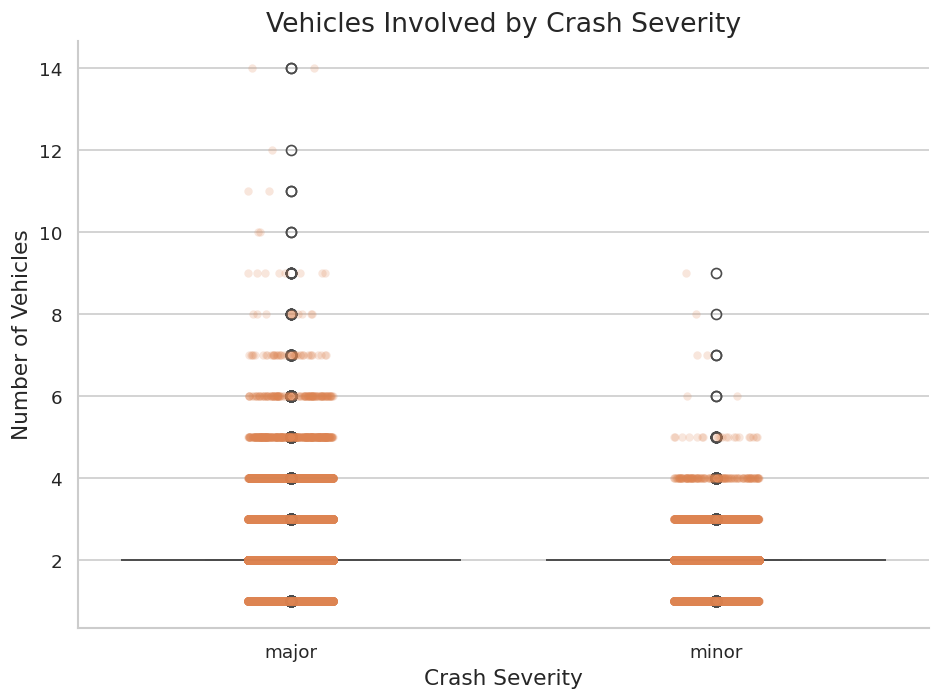

In [ ]:
# Vehicles vs Severity

sns.boxplot(x='crash_severity', y='num_vehicles_in_crash', data=df)
sns.stripplot(x='crash_severity', y='num_vehicles_in_crash', data=df,
              alpha=0.2, jitter=True)

plt.title('Vehicles Involved by Crash Severity')
plt.xlabel('Crash Severity')
plt.ylabel('Number of Vehicles')
sns.despine()
plt.tight_layout()
plt.show()

* The number of vehicles involved in a crash exhibits a noticeable relationship with crash severity. Major crashes tend to involve a higher number of vehicles and display greater variability, including extreme multi-vehicle incidents.

* In contrast, minor crashes are more tightly concentrated around lower vehicle counts. However, the overlap between the two categories indicates that while this feature contributes to severity prediction, it must be considered alongside other factors to achieve robust model performance.

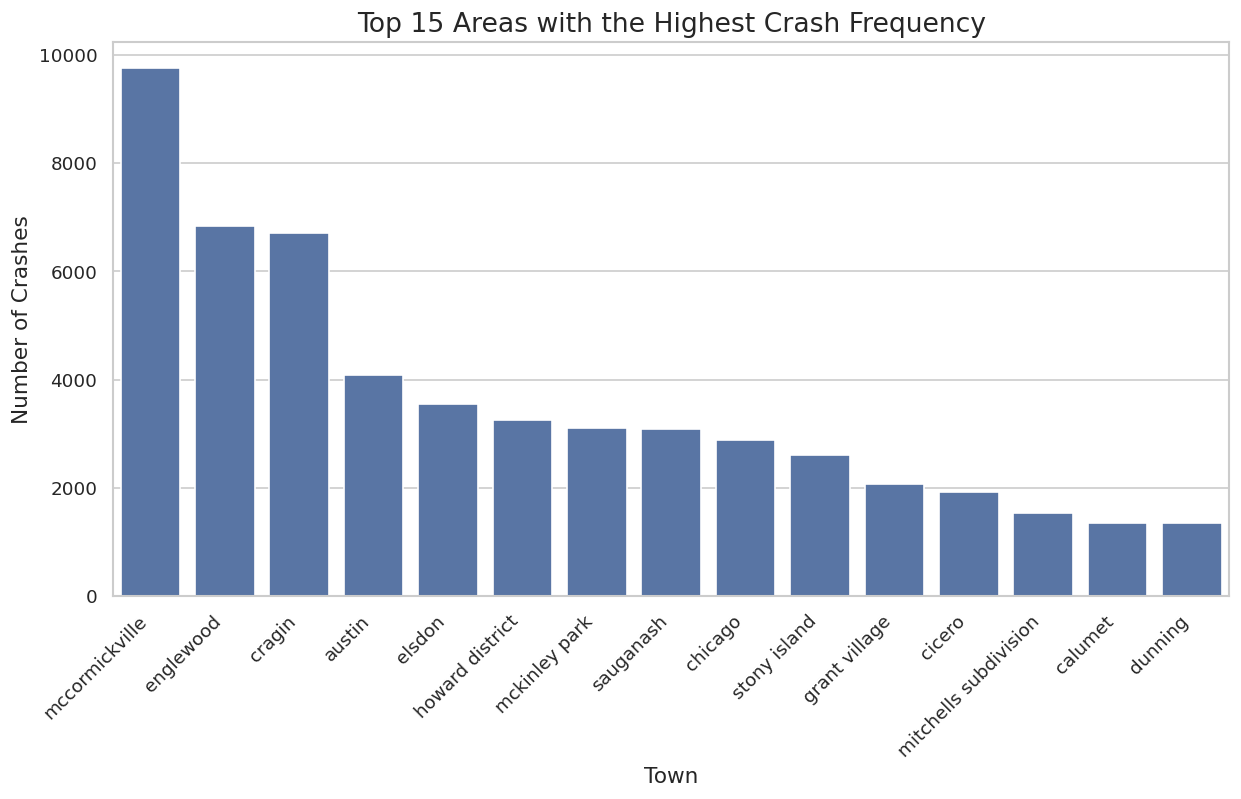

In [ ]:
# locations with highest frequency of crashes

top_towns = df['town'].value_counts().head(15)

plt.figure(figsize=(12, 6))
bar_plot = sns.barplot(x=top_towns.index, y=top_towns.values)

plt.title('Top 15 Areas with the Highest Crash Frequency')
plt.xlabel('Town')
plt.ylabel('Number of Crashes')

plt.xticks(rotation=45, ha='right')

plt.show()

* crash occurrences are concentrated in specific geographic hotspots, likely influenced by higher traffic volumes or urban infrastructure.

In [ ]:
# weather conditions

weather_conditions = df['conditions'].value_counts()

print(weather_conditions)

conditions
Partially cloudy          38947
Overcast                  13445
Clear                      5961
Rain, Overcast             3881
Rain, Partially cloudy     2471
Snow, Overcast              772
Snow, Partially cloudy      181
Rain                          6
Name: count, dtype: int64


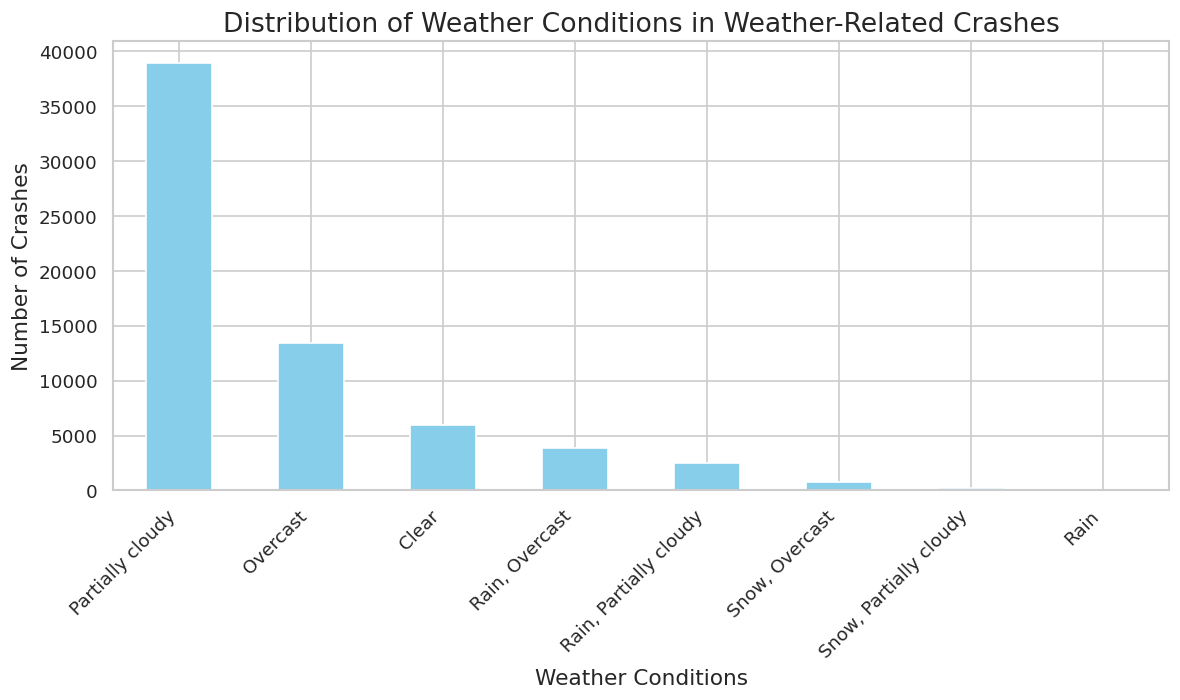

In [ ]:
plt.figure(figsize=(10, 6))
weather_conditions.plot(kind='bar', color='skyblue')
plt.title('Distribution of Weather Conditions in Weather-Related Crashes')
plt.xlabel('Weather Conditions')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=45, ha='right')  # Adjust rotation for better readability
plt.tight_layout()

# Show the plot
plt.show()

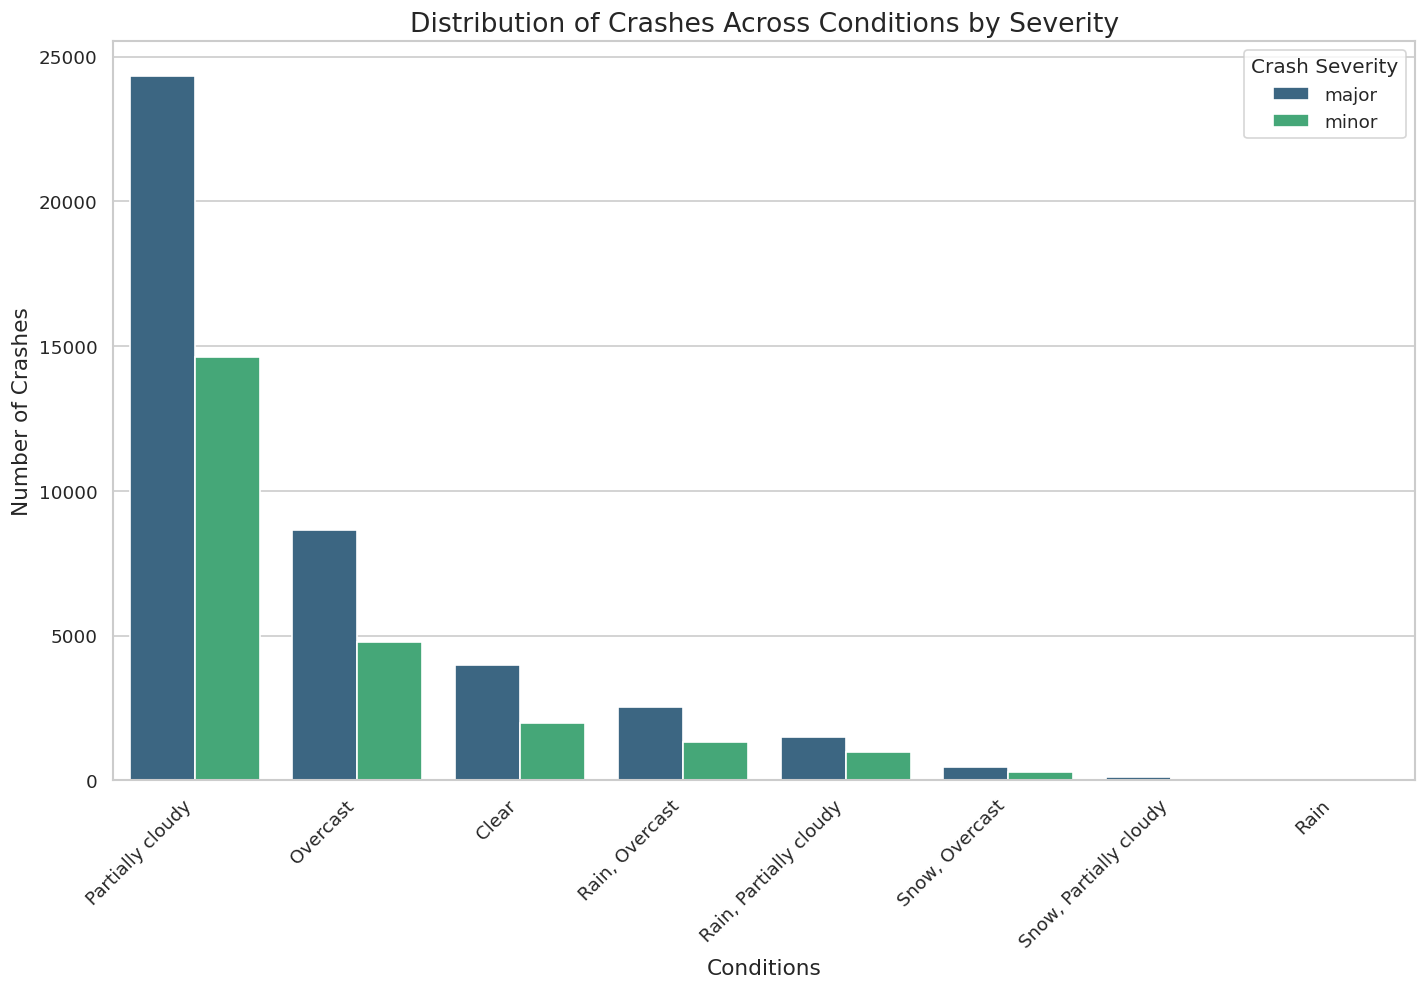

In [ ]:
plt.figure(figsize=(14, 8))
sns.countplot(x='conditions', hue='crash_severity', data=df, order=df['conditions'].value_counts().index, palette='viridis')
plt.title('Distribution of Crashes Across Conditions by Severity')
plt.xlabel('Conditions')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.legend(title='Crash Severity', loc='upper right')
plt.show()



* Overcast and Partially Cloudy weather are common during crashes, underscoring the importance of considering weather factors in road safety measures.

Text(0, 0.5, 'Total Killed')

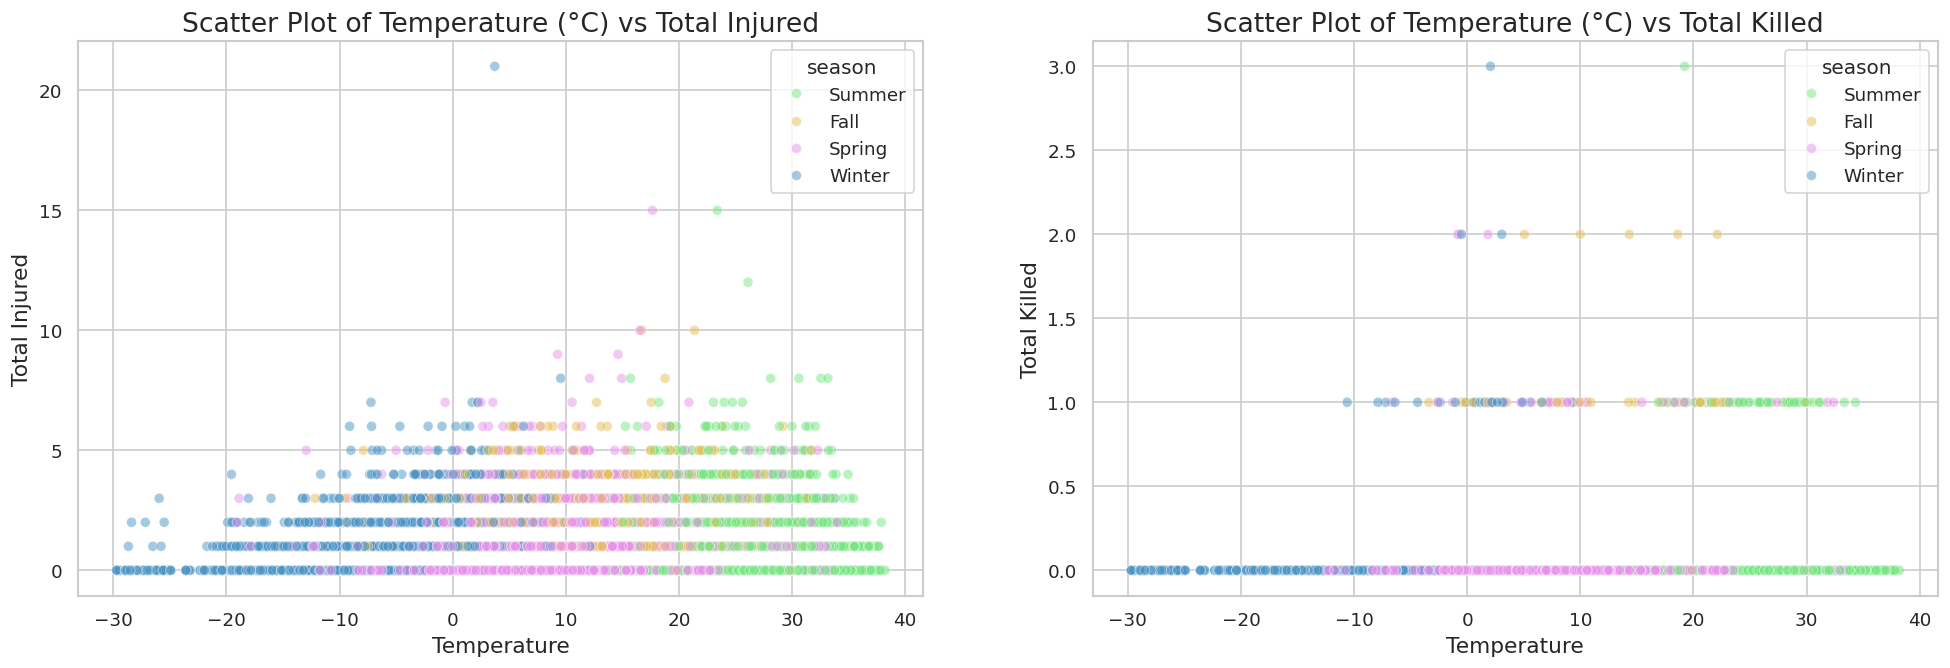

In [ ]:
# Crash severity By season

season_colors = {'Winter': '#4D95C4', 'Spring': '#E793EC', 'Summer': '#76E683', 'Fall': '#E7BF57'}

df['temp_cels'] = (df['temp'] - 32) * 5 / 9

filtered_data_injured = df[df['total_injured'] >= 0]

plt.figure(figsize=(20, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='temp_cels', y='total_injured', data=filtered_data_injured, alpha=0.5, palette=season_colors, hue='season', legend='full')
plt.title('Scatter Plot of Temperature (°C) vs Total Injured')
plt.xlabel('Temperature')
plt.ylabel('Total Injured')

filtered_data_killed = df[df['total_killed'] >= 0]

plt.subplot(1, 2, 2)
sns.scatterplot(x='temp_cels', y='total_killed', data=filtered_data_killed, alpha=0.5, palette=season_colors, hue='season', legend='full')
plt.title('Scatter Plot of Temperature (°C) vs Total Killed')
plt.xlabel('Temperature')
plt.ylabel('Total Killed')


* During the spring and early summer, road accidents occur with the highest frequency, likely attributable to increased outdoor activities and social events, including higher instances of drinking

In [ ]:
# Which Crash types are most fatal

crash_type_sum = df[df['total_killed'] >= 0].groupby('original_crash_type')['total_killed'].sum().reset_index()
crash_type_sum.columns = ['original_crash_type', 'total_killed']
crash_type_sum = crash_type_sum.sort_values(by='total_killed', ascending=False)

crash_type_sum

,original_crash_type,total_killed
9,pedestrian,46.0
2,fixed object,42.0
0,angle,26.0
3,head on,13.0
17,turning,13.0
7,parked motor vehicle,12.0
10,rear end,9.0
15,sideswipe same direction,4.0
8,pedalcyclist,4.0
5,other object,4.0


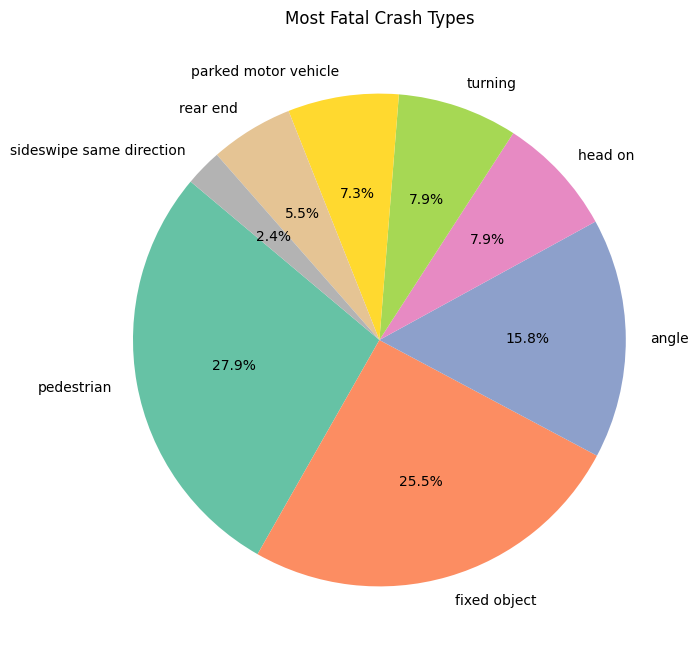

In [ ]:
sorted_crash_types = crash_type_sum.sort_values(by='total_killed', ascending=False)

top_n = 8
selected_crash_types = sorted_crash_types.head(top_n)

plt.figure(figsize=(8, 8))
colors = sns.color_palette('Set2', n_colors=top_n)
plt.pie(selected_crash_types['total_killed'], labels=selected_crash_types['original_crash_type'], autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Most Fatal Crash Types')
plt.show()

* Pedestrian crashes dominate fatalities (27.9%)

    * It highlights that vulnerable road users (pedestrians) are at the highest risk of fatal outcomes.
* Fixed object collisions are the second leading cause (25.5%)

    * These crashes often involve high-speed loss of control (e.g., hitting poles, trees, barriers).

* Angle crashes (15.8%) are a major contributor.

    * Indicates that intersection safety (signals, right-of-way violations) is a key factor in fatal outcomes.

* Fatal crashes are heavily concentrated in pedestrian and fixed-object incidents, indicating that vulnerability and impact severity mechanisms are the strongest drivers of fatal outcomes.

In [ ]:
# How does contributory cause affect severity ?

contributory_cause_table = df[df['total_killed'] >= 0].groupby('contributory_cause').agg({
    'total_killed': 'sum',
    'contributory_cause': 'count'
}).rename(columns={'contributory_cause': 'total_crashes'}).reset_index()

contributory_cause_table['death_ratio'] = (contributory_cause_table['total_killed'] / contributory_cause_table['total_crashes']) * 100

contributory_cause_table.sort_values(by='total_killed', ascending=False).head(10)

,contributory_cause,total_killed,total_crashes,death_ratio
36,unable to determine,63.0,52627,0.119710
17,failing to reduce speed to avoid crash,21.0,6303,0.333175
6,disregarding traffic signals,17.0,2964,0.573549
30,physical condition of driver,13.0,879,1.478953
18,failing to yield right-of-way,12.0,14289,0.083981
26,not applicable,10.0,6862,0.145730
28,"operating vehicle in erratic, reckless, carele...",9.0,1811,0.496963
37,under the influence of alcohol/drugs (use when...,7.0,761,0.919842
11,driving on wrong side/wrong way,4.0,786,0.508906
23,improper overtaking/passing,3.0,6289,0.047702


/tmp/ipykernel_2246/3134190081.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_killed', y='contributory_cause', data=top_conditions_total_killed, ax=axes[0], palette='viridis')
/tmp/ipykernel_2246/3134190081.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='death_ratio', y='contributory_cause', data=top_conditions_death_ratio, ax=axes[1], palette='plasma')


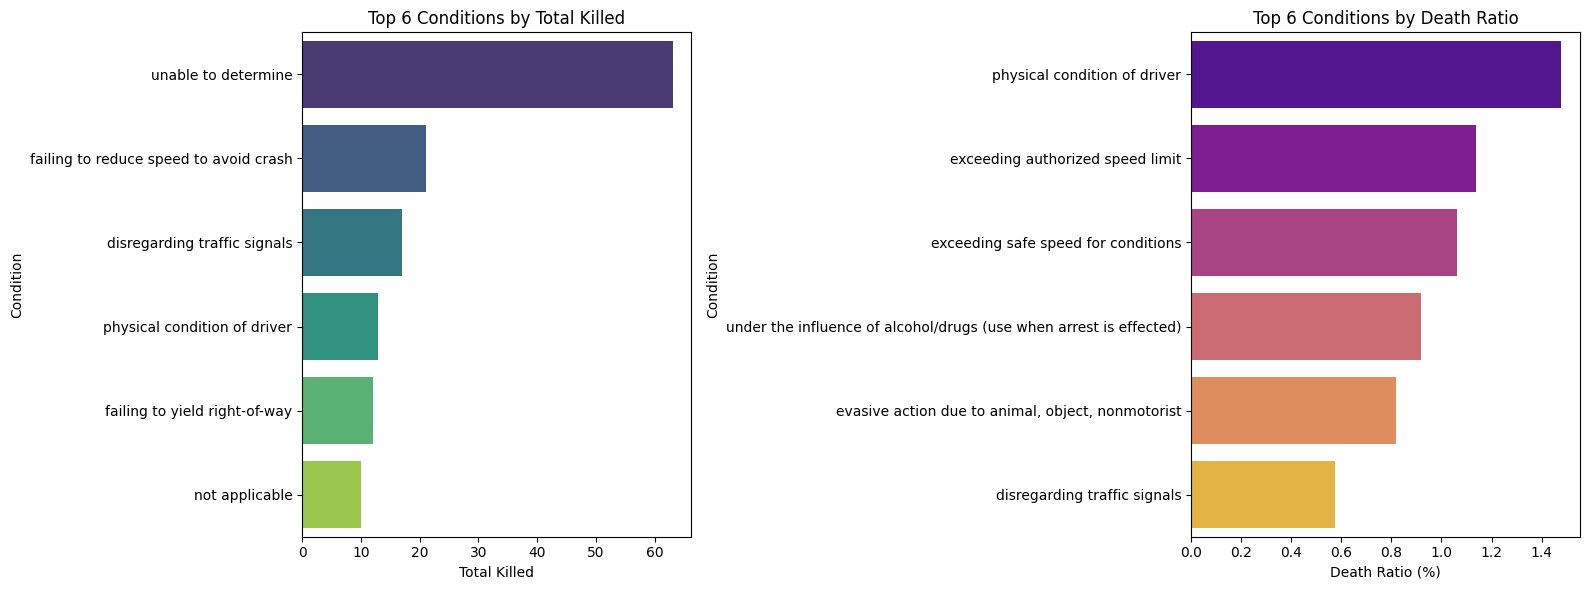

In [ ]:
top_conditions_total_killed = contributory_cause_table.sort_values('total_killed', ascending=False).head(6)
top_conditions_death_ratio = contributory_cause_table.sort_values('death_ratio', ascending=False).head(6)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='total_killed', y='contributory_cause', data=top_conditions_total_killed, ax=axes[0], palette='viridis')
axes[0].set_title('Top 6 Conditions by Total Killed')
axes[0].set_xlabel('Total Killed')
axes[0].set_ylabel('Condition')

sns.barplot(x='death_ratio', y='contributory_cause', data=top_conditions_death_ratio, ax=axes[1], palette='plasma')
axes[1].set_title('Top 6 Conditions by Death Ratio')
axes[1].set_xlabel('Death Ratio (%)')
axes[1].set_ylabel('Condition')

plt.tight_layout()
plt.show()

* Fatal crash outcomes are driven by a combination of high-frequency violations (e.g., speeding, signal disregard) and high-risk conditions (e.g., driver impairment), with speeding emerging as the most consistently dangerous factor across both total fatalities and fatality rate.

In [ ]:
# effect of road defects on car crash severity and frequency
road_defect_table = df[df['total_killed'] >= 0].groupby('road_defect').agg({
    'total_killed': 'sum',
    'total_injured': 'sum',
    'road_defect': 'count'
}).rename(columns={'road_defect': 'total_crashes'}).reset_index()

road_defect_table['death_ratio'] = (road_defect_table['total_killed'] / road_defect_table['total_crashes']) * 100
road_defect_table['injury_ratio'] = (road_defect_table['total_injured'] / road_defect_table['total_crashes']) * 100

road_defect_table

,road_defect,total_killed,total_injured,total_crashes,death_ratio,injury_ratio
0,debris on roadway,1.0,28.0,121,0.826446,23.140496
1,no defects,141.0,22759.0,108288,0.130208,21.017103
2,other,3.0,128.0,681,0.440529,18.795888
3,"rut, holes",0.0,125.0,1043,0.000000,11.984660
4,shoulder defect,0.0,70.0,244,0.000000,28.688525
5,unknown,28.0,3866.0,22604,0.123872,17.103168
6,worn surface,3.0,135.0,497,0.603622,27.162978


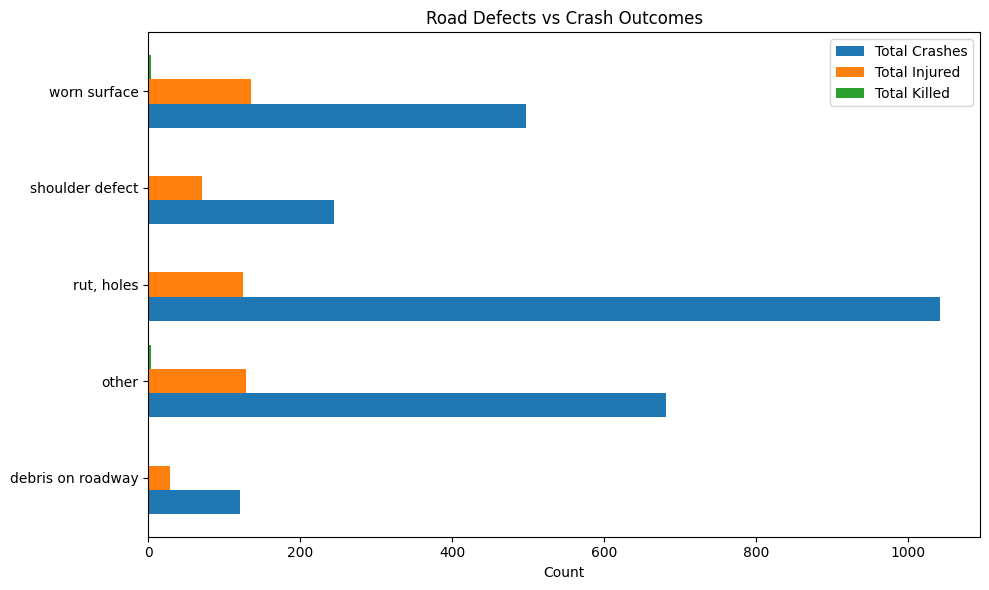

In [ ]:
filtered = road_defect_table[
    ~road_defect_table['road_defect'].isin(['no defects', 'unknown'])
]

y = np.arange(len(filtered))
width = 0.25

plt.figure(figsize=(10,6))

plt.barh(y - width, filtered['total_crashes'], height=width, label='Total Crashes')
plt.barh(y, filtered['total_injured'], height=width, label='Total Injured')
plt.barh(y + width, filtered['total_killed'], height=width, label='Total Killed')

plt.yticks(y, filtered['road_defect'])
plt.xlabel('Count')
plt.title('Road Defects vs Crash Outcomes')
plt.legend()

plt.tight_layout()
plt.show()

* Road defects like rut holes and worn surfaces drive crash frequency, but their impact on fatal outcomes is relatively small compared to behavioral factors.

# ***Results***

---



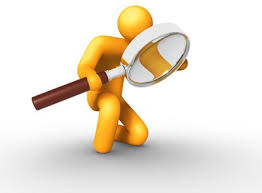

1. Time Analysis

Crashes peak between 2:00 PM and 5:00 PM, reflecting heavy afternoon traffic. However, nighttime crashes tend to be more severe, likely due to reduced visibility and limited lighting.

2. Day of Week Analysis

Fridays have the highest crash frequency, consistent with increased travel. However, Saturdays record more fatal injuries, suggesting higher-risk driving conditions over the weekend.

3. Contributing Factors

Common causes include failure to yield, following too closely, improper overtaking, poor speed adjustment, and unsafe backing. These highlight the major role of driver behavior in crash occurrence.

4. Weather and Seasonality

Crashes are more frequent during spring and early summer and under mild weather conditions, likely due to increased travel and a false sense of safety rather than hazardous conditions.

5. Fatality Risk

Pedestrian crashes and fixed-object collisions are more likely to be fatal. Factors like driver impairment and traffic signal violations significantly increase severity.

6. Environmental Insight

Crashes often occur in normal conditions, indicating that exposure and human behavior are stronger drivers than weather alone.

7. Practical Implications

Focus safety efforts on high-risk times (afternoons, nights, weekends) and behavioral factors. Use data-driven strategies to improve road safety and reduce severe outcomes.

# **Recommendations**

---



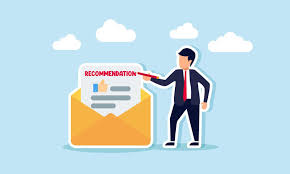

* Exercise extra caution during peak traffic hours between 2:00 PM and 5:00 PM, prioritizing heightened attentiveness and defensive driving.

* Acknowledge the increased risk of severe accidents during nighttime hours, despite lower traffic. Ensure proper visibility, adhere to speed limits, and stay alert on less congested roads.

* Stay vigilant on Fridays, the day with the highest overall crash frequency, and exercise heightened awareness on Saturdays, which record the most fatal injuries.

* Address common contributors to accidents, including right-of-way issues, maintaining a safe following distance, overtaking, adjusting speed, and improper backing maneuvers.

* Be aware that most crashes occur during spring and early summer, challenging assumptions about increased accidents during adverse weather conditions.


# **Vehicle Safety Board Initiatives to Lower Crash Rates**

---



* Launch targeted public awareness campaigns to educate drivers about peak hours, risks during nighttime driving, and specific challenges associated with weekends and certain seasons.

* Strengthen law enforcement efforts targeting common contributors to crashes, such as right-of-way violations, following too closely, and speeding.

* Evaluate and improve road infrastructure, especially at intersections and areas prone to fixed object collisions, to enhance overall road safety.

* Implement traffic management strategies, including adjusting signal timings during peak hours and at night, to improve traffic flow and reduce the likelihood of accidents.

* Collaborate with local communities to gather insights and feedback, fostering community engagement and contributing to the development of context-specific solutions.
